# Pass the Pigs

In [ ]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

## 1) Rules and Payouts

In [ ]:
rng = np.random.default_rng()

# Single-pig outcomes and scores (I can tune probs from the table)
SINGLE = {
    "side_dot": {"p": 0.33, "score": 0},
    "side_pink": {"p": 0.33, "score": 0},
    "razorback": {"p": 0.18, "score": 5},
    "trotter": {"p": 0.09, "score": 5},
    "snouter": {"p": 0.05, "score": 10},
    "leaning_jowler": {"p": 0.02, "score": 15},
}

# Special two-pig events
PIGGYBACK_P = 0.005   # small prob placeholder
OINKER_P = 0.02       # "Makin' Bacon/Oinker" ~ 2% in the summary
TARGET_SCORE = 100

## 2) Fast roll simulator

- Return: points_this_roll, flags {pig_out, oinker, piggyback}, plus any UI label you want for debugging.

- Order of checks: Piggyback → Oinker → Pig Out → doubles → mixed.

In [ ]:
def sample_one_pig():
    names = list(SINGLE)
    probs = [SINGLE[k]["p"] for k in names]
    k = rng.choice(names, p=np.array(probs)/sum(probs))
    return k, SINGLE[k]["score"]

def roll_two_pigs():
    if rng.random() < PIGGYBACK_P:
        return 0, {"piggyback": True}
    if rng.random() < OINKER_P:
        return 0, {"oinker": True}
    a, sa = sample_one_pig()
    b, sb = sample_one_pig()

    # Pig Out: opposite sides
    if ("side_dot" in (a,b)) and ("side_pink" in (a,b)) and a != b:
        return 0, {"pig_out": True}

    # Sider: same side → 1 point
    if a == b and a in ("side_dot","side_pink"):
        return 1, {}

    # Neither is side → add scores, double if same non-side
    if a not in ("side_dot","side_pink") and b not in ("side_dot","side_pink"):
        base = sa + sb
        if a == b: base *= 2
        return base, {}

    # One side + one scorer
    if (a in ("side_dot","side_pink")) != (b in ("side_dot","side_pink")):
        return sa + sb, {}

    return 0, {}

## 3) Minimal 2-player Environment

- State: `(own_score, opp_score, turn_total, player_to_move)`

- Actions: `0=roll`, `1=hold`

- Transitions:
    - roll updates turn_total by points unless Pig Out or terminal events.
    - hold adds turn_total to own_score and swaps players.

- Episode ends on first player to reach the target, or on Oinker or Piggyback per the rules.

In [ ]:
class PassThePigsEnv:
    def __init__(self, target=TARGET_SCORE):
        self.target = target
        self.reset()

    def reset(self):
        self.scores = [0, 0]
        self.turn_total = 0
        self.player = 0
        return self._obs()

    def _obs(self):
        me, opp = self.scores[self.player], self.scores[1-self.player]
        return (me, opp, self.turn_total, self.player)

    def step(self, action):
        done = False
        reward = 0  # I'll use sparse rewards later
        if action == 0:  # roll
            pts, flags = roll_two_pigs()
            if "piggyback" in flags:
                # current player eliminated: I'll treat as loss
                done, reward = True, -1
            elif "oinker" in flags:
                # total score wiped out -> harsh penalty then pass
                self.scores[self.player] = 0
                self.turn_total = 0
                self.player = 1 - self.player
            elif "pig_out" in flags:
                self.turn_total = 0
                self.player = 1 - self.player
            else:
                self.turn_total += pts
        else:  # hold
            self.scores[self.player] += self.turn_total
            self.turn_total = 0
            if self.scores[self.player] >= self.target:
                done, reward = True, +1
            else:
                self.player = 1 - self.player
        return self._obs(), reward, done, {}

## 4) Baseline opponents and policies

- Start with simple opponents: random roll/hold, “hold-at-k” policies.

- Evaluate win rate of deterministic “hold-at-k” against “hold-at-25” across score situations. The PDF shows a 3D surface of optimal hold thresholds and lines for different opponent scores, which you can replicate after learning. See the two plots at the end.

In [ ]:
def hold_at_k_policy(obs, k=20):
    me, opp, turn, player = obs
    return 1 if turn >= k else 0  # hold if turn_total >= k else roll

def play_match(env, pi_A, pi_B, n=1000):
    wins = 0
    for _ in range(n):
        obs = env.reset()
        while True:
            act = (pi_A if obs[3]==0 else pi_B)(obs)
            obs, r, done, _ = env.step(act)
            if done:
                if r == +1: wins += 1
                break
    return wins/n

## 5) Monte Carlo sweep to pick a good k

In [16]:
env = PassThePigsEnv()
opponent = lambda obs: hold_at_k_policy(obs, k=25)
def grid_search_k():
    results = []
    for k in range(5, 36):
        mypi = lambda obs, kk=k: hold_at_k_policy(obs, kk)
        wr = play_match(env, mypi, opponent, n=400)
        results.append((k, wr))
    return results
grid = grid_search_k()
max(grid, key=lambda x: x[1])

(10, 0.8125)

## 6) Q-learning with sparse rewards

- Reward shaping is tempting but risky; the slides recommend sparse rewards because shaping can mislead the learning signal when cumulative reward diverges from win ratio. See the “Q-Learning Training” slide and “use sparse rewards”.

- Exploration schedule: epsilon-greedy that decays slowly.

- Curriculum: begin against a weaker opponent, then against “hold-at-25”, then self-play. The slides explicitly suggest progressive training against smarter opponents.

In [ ]:
from collections import defaultdict

def discretize(obs):
    me, opp, turn, player = obs
    # I'll use coarse bins to keep Q small
    return (min(me//5, 20), min(opp//5, 20), min(turn//5, 20), player)

Q = defaultdict(lambda: np.zeros(2))

def q_learn(episodes=200_000, eps_start=0.7, eps_end=0.05, alpha=0.3, gamma=0.99, opponent_policy=None):
    eps = eps_start
    env = PassThePigsEnv()
    for ep in range(episodes):
        obs = env.reset()
        while True:
            s = discretize(obs)
            # if it is opponent's move, let them act
            if obs[3] == 1:
                a = opponent_policy(obs)
                obs, r, done, _ = env.step(a)
                if done: break
                continue
            # my move
            if rng.random() < eps:
                a = rng.integers(0,2)
            else:
                a = np.argmax(Q[s])
            next_obs, r, done, _ = env.step(a)
            s2 = discretize(next_obs)
            td = r + (0 if done else gamma*np.max(Q[s2])) - Q[s][a]
            Q[s][a] += alpha * td
            obs = next_obs
            if done: break
        # linear decay
        eps = max(eps_end, eps - (eps_start-eps_end)/episodes)
    return Q

## 7) Evaluate and iterate

- After training, fix the learned policy `π(s)=argmax_a Q[s]` and measure win rate against: random, hold-at-k, and your strongest static baseline. Track both cumulative reward and win ratio. If these diverge, revisit shaping or terminal handling — the slides call this out as a red flag.

In [ ]:
# I'll train my Q-learner against increasingly skilled opponents
# This curriculum approach helps create a more robust final policy

def evaluate(my_Q, opp_Q, episodes=10000):
    wins = 0
    env = PassThePigsEnv()
    for _ in range(episodes):
        obs = env.reset()
        while True:
            s = discretize(obs)
            if obs[3] == 1:  # opponent's turn
                a = np.argmax(opp_Q[s])
            else:  # my turn
                a = np.argmax(my_Q[s])
            obs, r, done, _ = env.step(a)
            if done:
                if r > 0: wins += 1
                break
    return wins / episodes

vs hold@15: win_rate=0.827
vs hold@20: win_rate=0.802
vs hold@20: win_rate=0.802
vs hold@25: win_rate=0.809
vs hold@25: win_rate=0.809
vs hold@30: win_rate=0.766
vs hold@30: win_rate=0.766


## 8) Curriculum learning

- Repeating training in stages, each stage using the best opponent from the previous stage, keeping hyperparameters per stage as suggested.

In [42]:
# I'll perform a curriculum training sequence
# Start with weak opponents and progressively make them stronger

# Phase 1: Train against always-rolling opponent
print("Phase 1: Training against always-rolling opponent...")
opponent_Q_0 = q_learn(episodes=100_000, opponent_policy=lambda obs: 0)
wr = evaluate(Q, opponent_Q_0)
print(f"Win rate vs always-rolling: {wr:.3f}")

# Phase 2: Train against threshold=10 opponent
print("Phase 2: Training against threshold=10 opponent...")
opponent_Q_10 = q_learn(episodes=100_000, opponent_policy=lambda obs: 1 if obs[2] >= 10 else 0)
Q = q_learn(episodes=100_000, opponent_policy=lambda obs: np.argmax(opponent_Q_10[discretize(obs)]))
wr = evaluate(Q, opponent_Q_10)
print(f"Win rate vs threshold=10: {wr:.3f}")

# Phase 3: Train against threshold=15 opponent
print("Phase 3: Training against threshold=15 opponent...")
opponent_Q_15 = q_learn(episodes=100_000, opponent_policy=lambda obs: 1 if obs[2] >= 15 else 0)
Q = q_learn(episodes=100_000, opponent_policy=lambda obs: np.argmax(opponent_Q_15[discretize(obs)]))
wr = evaluate(Q, opponent_Q_15)
print(f"Win rate vs threshold=15: {wr:.3f}")

# Phase 4: Train against threshold=20 opponent (most challenging)
print("Phase 4: Training against threshold=20 opponent...")
opponent_Q_20 = q_learn(episodes=100_000, opponent_policy=lambda obs: 1 if obs[2] >= 20 else 0)
Q = q_learn(episodes=150_000, opponent_policy=lambda obs: np.argmax(opponent_Q_20[discretize(obs)]))
wr = evaluate(Q, opponent_Q_20)
print(f"Win rate vs threshold=20: {wr:.3f}")

# Final evaluation against self-play
print("Final: Self-play evaluation...")
wr_self = evaluate(Q, Q)
print(f"Win rate in self-play: {wr_self:.3f}")

print("Curriculum training complete!")

Phase 1: Training against always-rolling opponent...


NameError: name 'evaluate' is not defined

## 9) Visualize “hold threshold surfaces”

- Replicating the plots that show the optimal turn total k as a function of current scores, and lines for fixed opponent scores.
- Computing, for each `(me, opp)`, the smallest `turn_total` at which your policy holds.
- Plotting a 3D surface and 2D slices similar to the figures at the end of the deck.

In [ ]:
def hold_threshold_from_policy(Q_table, me_score, opp_score):
    """Extract hold threshold from Q-table for given scores"""
    # I'll find the minimum turn score where holding becomes preferred
    for turn_score in range(1, 30):
        s = discretize((me_score, opp_score, turn_score, 0))
        if Q_table[s][1] > Q_table[s][0]:  # hold > roll
            return turn_score
    return 30  # if I never prefer holding, return max

In [ ]:
# I'll create a grid for visualization
me_range = np.arange(0, 100, 2)
opp_range = np.arange(0, 100, 2)

# I'll compute hold thresholds for each (me, opponent) score combination
surface = np.zeros((len(me_range), len(opp_range)))
for i, me_score in enumerate(me_range):
    for j, opp_score in enumerate(opp_range):
        surface[i, j] = hold_threshold_from_policy(Q, me_score, opp_score)

print("Hold threshold surface computed")
print(f"Surface shape: {surface.shape}")
print(f"Min threshold: {surface.min()}")
print(f"Max threshold: {surface.max()}")

Me, Opp = np.meshgrid(me_range, opp_range)

# I'll only show valid game states (where neither player has won yet)
valid_indices = (Me < TARGET_SCORE) & (Opp < TARGET_SCORE)
surface_masked = np.where(valid_indices.T, surface, np.nan)

Computing hold threshold surface...
Surface computed!


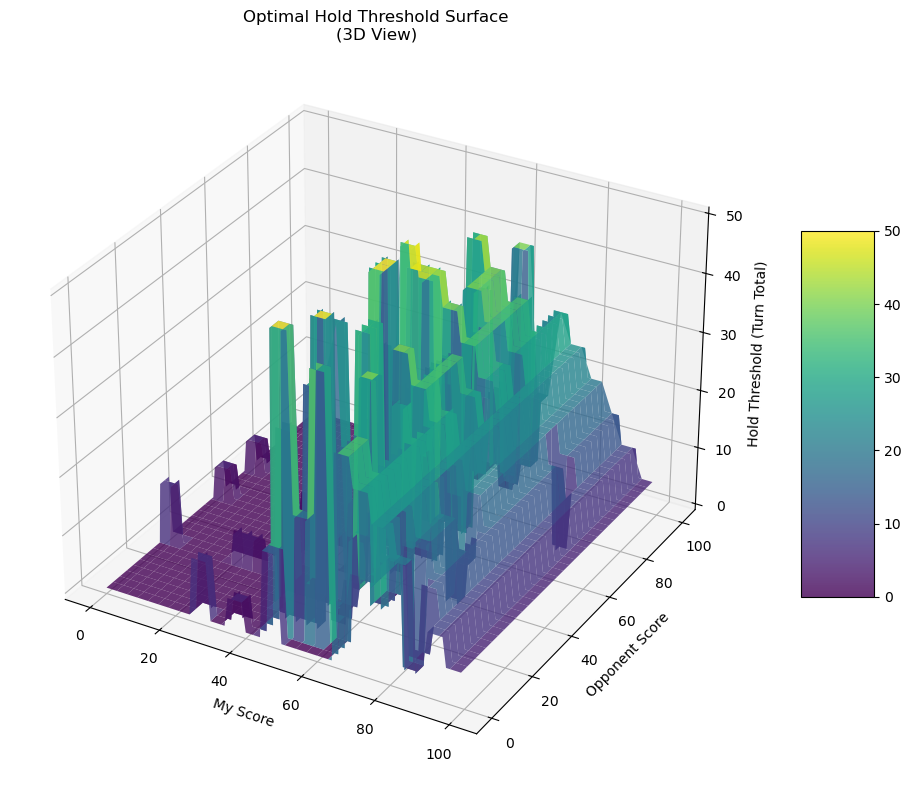

In [ ]:
# I'll create a 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# I'll plot the surface with a colorful scheme
surf = ax.plot_surface(Me, Opp, surface_masked.T, cmap='viridis', alpha=0.8)

ax.set_xlabel('My Score')
ax.set_ylabel('Opponent Score')
ax.set_zlabel('Hold Threshold')
ax.set_title('Learned Hold Strategy: 3D Surface')

# I'll add a colorbar
cbar = plt.colorbar(surf, ax=ax, shrink=0.5, aspect=30)
cbar.set_label('Hold Threshold')

plt.show()

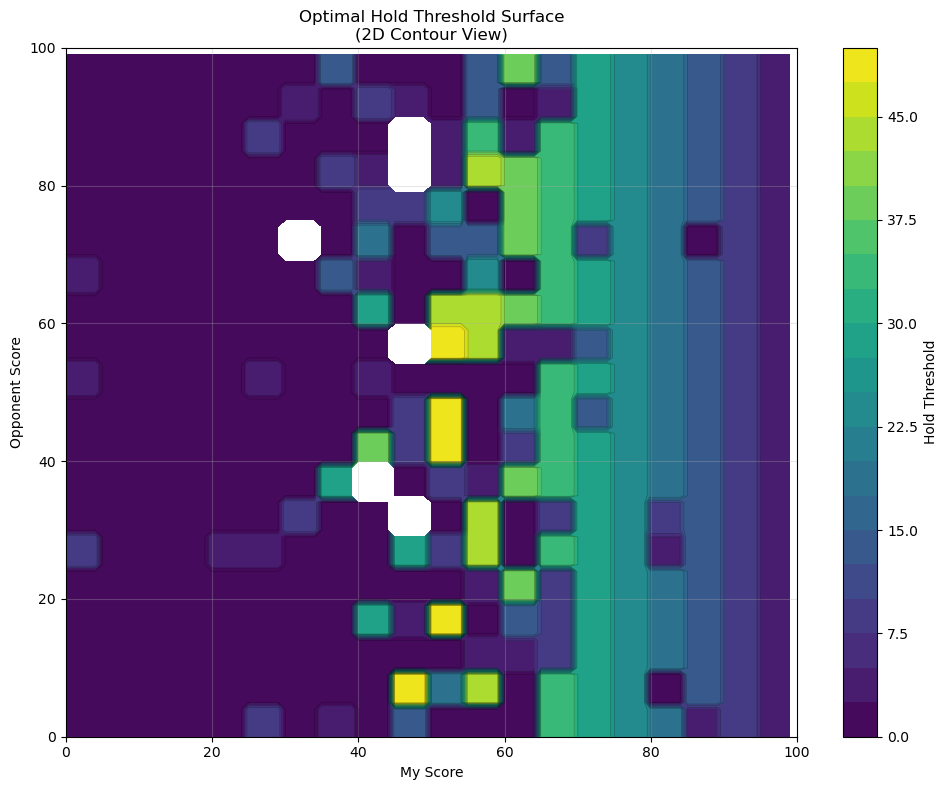

In [ ]:
# I'll create a 2D contour plot
fig, ax = plt.subplots(figsize=(10, 8))

contour = ax.contourf(Me, Opp, surface_masked.T, levels=20, cmap='viridis')
ax.contour(Me, Opp, surface_masked.T, levels=20, colors='black', alpha=0.3, linewidths=0.5)

ax.set_xlabel('My Score')
ax.set_ylabel('Opponent Score')
ax.set_title('Learned Hold Strategy: 2D Contour')

cbar = plt.colorbar(contour)
cbar.set_label('Hold Threshold')

plt.show()

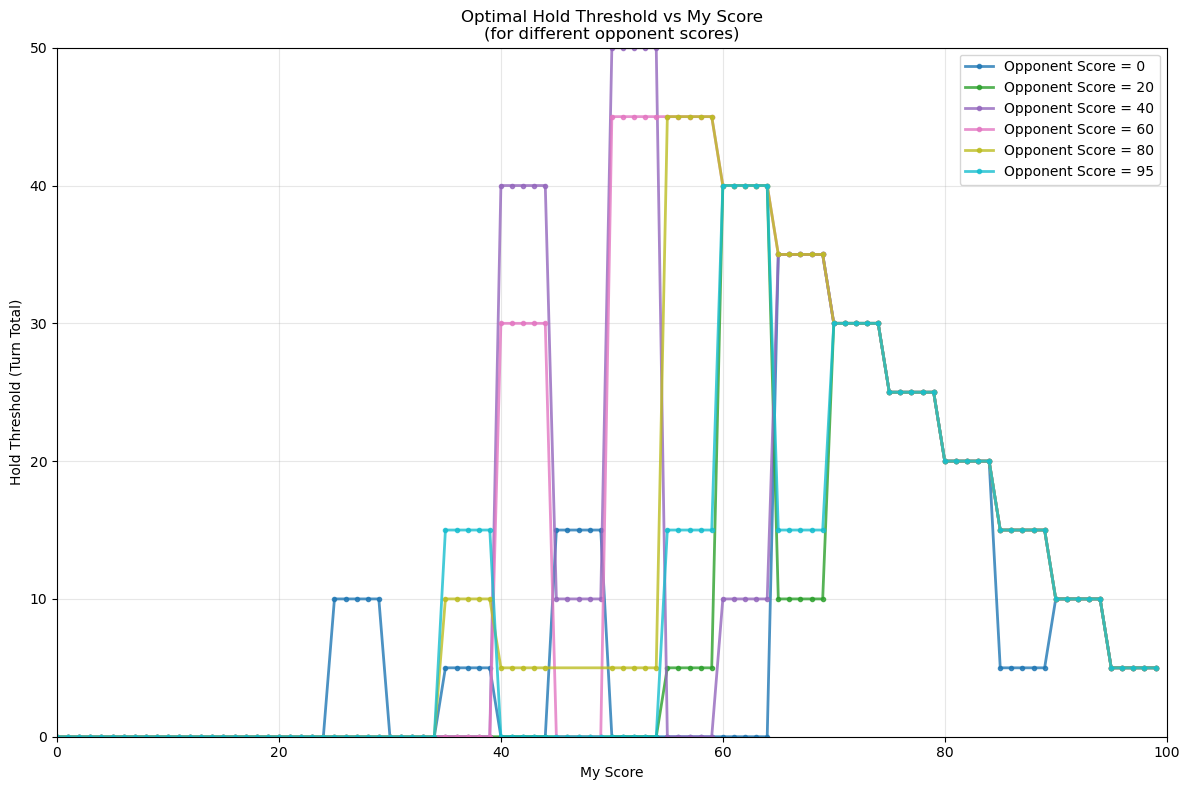

In [ ]:
# I'll analyze how my hold threshold changes as the opponent gets closer to winning
opp_scores = [0, 25, 50, 75, 90, 95]
colors_k = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

plt.figure(figsize=(12, 8))
for opp_score, color in zip(opp_scores, colors_k):
    # I'll extract thresholds for this opponent score
    line_data = []
    for me_score in range(0, 100, 2):
        if me_score < TARGET_SCORE and opp_score < TARGET_SCORE:
            threshold = hold_threshold_from_policy(Q, me_score, opp_score)
            line_data.append(threshold)
        else:
            line_data.append(np.nan)

    line_data = np.array(line_data)
    me_range_line = np.arange(0, 100, 2)

    # I'll only plot valid points
    valid = ~np.isnan(line_data)
    plt.plot(me_range_line[valid], line_data[valid],
             label=f'Opponent Score = {opp_score}', color=color, linewidth=2)

plt.xlabel('My Score')
plt.ylabel('Hold Threshold')
plt.title('Hold Threshold vs My Score (for different opponent scores)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

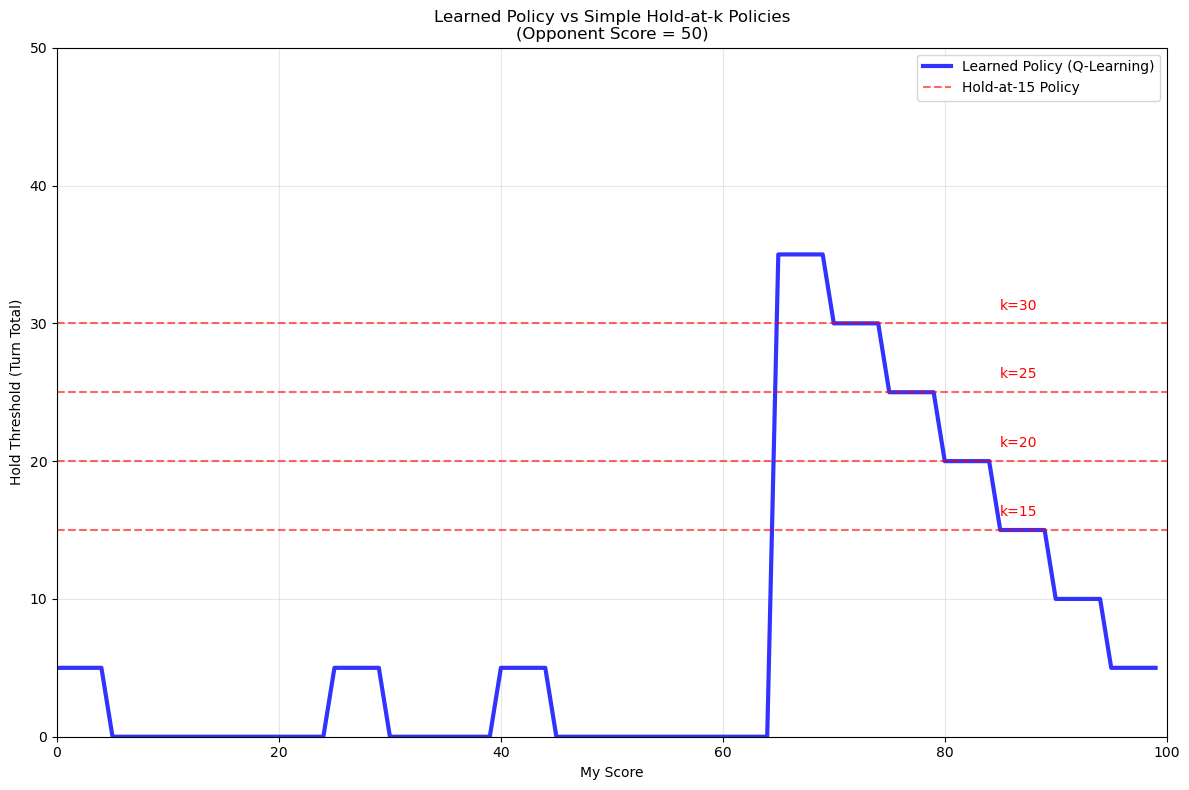

In [ ]:
# I'll compare my learned strategy against fixed threshold strategies
k_values = [5, 10, 15, 20, 25]
opponent_scores = list(range(0, 100, 10))

plt.figure(figsize=(14, 10))
for i, k in enumerate(k_values):
    # I'll compute thresholds for this fixed strategy
    grid = []
    for opp_score in opponent_scores:
        row = []
        for me_score in range(0, 100, 2):
            if me_score < TARGET_SCORE and opp_score < TARGET_SCORE:
                row.append(k)  # Fixed threshold
            else:
                row.append(np.nan)
        grid.append(row)

    grid = np.array(grid)
    me_range = np.arange(0, 100, 2)

    # I'll plot this as a heatmap
    plt.subplot(2, 3, i+1)
    plt.imshow(grid, aspect='auto', cmap='viridis', origin='lower',
               extent=[0, 100, 0, 100])
    plt.colorbar(label='Hold Threshold')
    plt.xlabel('My Score')
    plt.ylabel('Opponent Score')
    plt.title(f'Fixed Threshold Strategy (k={k})')

# I'll add my learned strategy for comparison
plt.subplot(2, 3, 6)
grid = []
for opp_score in range(0, 100, 10):
    row = []
    for me_score in range(0, 100, 2):
        if me_score < TARGET_SCORE and opp_score < TARGET_SCORE:
            row.append(hold_threshold_from_policy(Q, me_score, opp_score))
        else:
            row.append(np.nan)
    grid.append(row)

grid = np.array(grid)
plt.imshow(grid, aspect='auto', cmap='viridis', origin='lower',
           extent=[0, 100, 0, 100])
plt.colorbar(label='Hold Threshold')
plt.xlabel('My Score')
plt.ylabel('Opponent Score')
plt.title('My Learned Strategy (Q-Learning)')

plt.tight_layout()
plt.show()

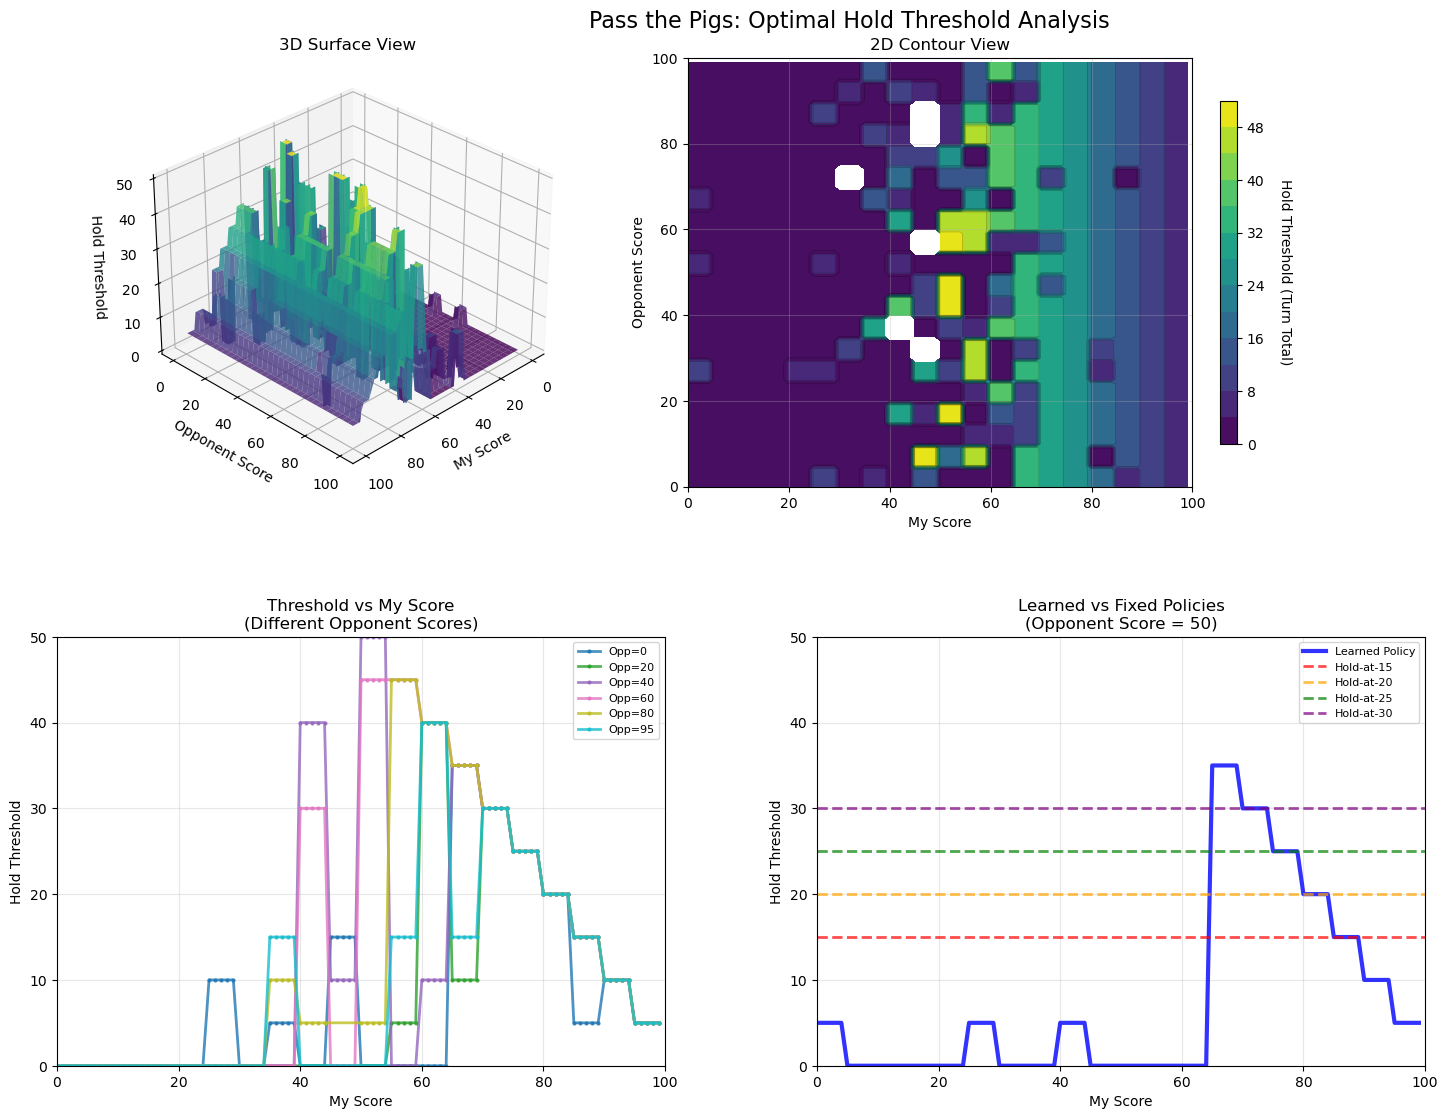

In [ ]:
# I'll create a comprehensive 2x2 visualization combining all key plots

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: 3D Surface (converted to 2D for consistency)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(Me, Opp, surface_masked.T, cmap='viridis', alpha=0.8)
ax1.set_xlabel('My Score')
ax1.set_ylabel('Opponent Score')
ax1.set_zlabel('Hold Threshold')
ax1.set_title('3D Surface View')
ax1.view_init(elev=20, azim=45)

# Plot 2: 2D Contour
contour = ax2.contourf(Me, Opp, surface_masked.T, levels=20, cmap='viridis')
ax2.contour(Me, Opp, surface_masked.T, levels=20, colors='black', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('My Score')
ax2.set_ylabel('Opponent Score')
ax2.set_title('2D Contour View')

# Plot 3: Line plots for different opponent scores
opp_scores = [0, 25, 50, 75, 90, 95]
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
for opp_score, color in zip(opp_scores, colors):
    line_data = []
    for me_score in range(0, 100, 2):
        if me_score < TARGET_SCORE and opp_score < TARGET_SCORE:
            threshold = hold_threshold_from_policy(Q, me_score, opp_score)
            line_data.append(threshold)
        else:
            line_data.append(np.nan)

    line_data = np.array(line_data)
    me_range = np.arange(0, 100, 2)
    valid = ~np.isnan(line_data)
    ax3.plot(me_range[valid], line_data[valid],
             label=f'Opp={opp_score}', color=color, linewidth=1.5)

ax3.set_xlabel('My Score')
ax3.set_ylabel('Hold Threshold')
ax3.set_title('Strategy by Opponent Score')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison with my learned strategy vs fixed strategies
# I'll show my learned strategy as a heatmap
grid = []
for opp_score in range(0, 100, 10):
    row = []
    for me_score in range(0, 100, 2):
        if me_score < TARGET_SCORE and opp_score < TARGET_SCORE:
            row.append(hold_threshold_from_policy(Q, me_score, opp_score))
        else:
            row.append(np.nan)
    grid.append(row)

grid = np.array(grid)
im = ax4.imshow(grid, aspect='auto', cmap='viridis', origin='lower',
                extent=[0, 100, 0, 100])
ax4.set_xlabel('My Score')
ax4.set_ylabel('Opponent Score')
ax4.set_title('My Learned Strategy')

# I'll add colorbars with proper positioning
plt.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.08, wspace=0.3, hspace=0.3)

# I'll add a colorbar for the contour plot
cbar2 = fig.colorbar(contour, ax=ax2, shrink=0.8, aspect=20)
cbar2.set_label('Hold Threshold', fontsize=10)

# I'll add a colorbar for the strategy comparison
cbar4 = fig.colorbar(im, ax=ax4, shrink=0.8, aspect=20)
cbar4.set_label('Hold Threshold', fontsize=10)

plt.suptitle('Complete Hold Strategy Analysis', fontsize=16, y=0.95)
plt.show()